# Titanic Exploratory Data Analysis

## Objective 

The goal of this notebook is to explore the Titanic dataset and identify the factors that influenced passenger survival.
The analysis covers data cleaning, visualization of key survival factors, and a short written summary of findings.

# 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# 2. Loading the Dataset

In [2]:
df = pd.read_csv("../data/titanic.csv")

# 3. Dataset Overview

In [3]:
print(f'Shape: {df.shape}')
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [6]:
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum()>0])

Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64


Three columns have missing data: `Age` (177 missing), `Cabin` (687 missing), and `Embarked` (2 missing). Each is handled differently in the cleaning section below.

# 4. Data Cleaning

In [7]:
df_clean = df.copy()

### 4.1 Age

About 20% of `Age` values are missing. Dropping these rows would remove a significant portion of the dataset and could introduce bias. Filling with the global median is simple but ignores the fact that age varies by class and gender - a 1st-class male passenger is likely older than a 3rd-class female. So instead, the missing values are filled with the **median age grouped by `Pclass` and `Sex`**, which gives a more realistic estimate for each subgroup.

In [8]:
df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
print(f'Missing Age values remaining: {df_clean["Age"].isnull().sum()}')

Missing Age values remaining: 0


### 4.2 Embarked

Only 2 values are missing in the `Embarked` column. To preserve all observations, the missing values are filled using the **mode (most frequent value)**, which is **Southampton (`S`)**. Since only two records are affected, this choice has minimal impact on the analysis.

In [9]:
df_clean['Embarked'] = df_clean['Embarked'].fillna(
    df_clean['Embarked'].mode()[0]
)
print("Missing Embarked values remaining:",
      df_clean["Embarked"].isnull().sum())

Missing Embarked values remaining: 0


### 4.3 Cabin

Over 77% of `Cabin` values are missing. Imputing this many values would mean fabricating most of the column, which is not appropriate. Rather than dropping or guessing, a binary column `Has_Cabin` is created (1 if a cabin was recorded, 0 if not) to preserve the signal that cabin availability might carry (it correlates with class), and the original column is then dropped.

In [10]:
df_clean['Has_Cabin']=df_clean['Cabin'].notnull()
df_clean['Has_Cabin']=df_clean['Has_Cabin'].replace({
    True: 1,
    False: 0
})
df_clean.drop(columns=['Cabin'], inplace=True)
print(df_clean['Has_Cabin'].value_counts())

Has_Cabin
0    687
1    204
Name: count, dtype: int64


### 4.4 Verification

In [11]:
remaining = df_clean.isnull().sum()
print('Remaining missing values:')
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None — cleaning complete.')
print(f'\nFinal shape: {df_clean.shape}')

Remaining missing values:
None — cleaning complete.

Final shape: (891, 12)


## 5. Exploratory Data Analysis

### 5.1 Survival Distribution

Before looking at individual factors, it helps to see the overall split: how many passengers survived?

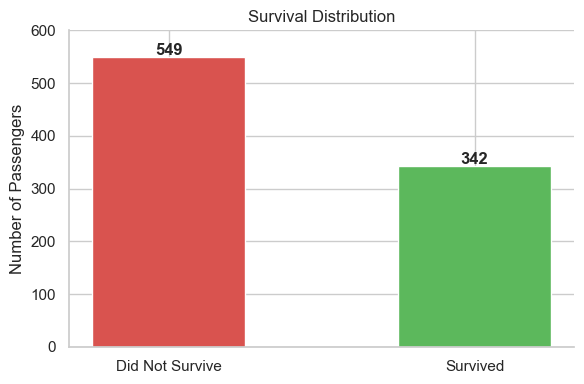

Survival rate: 38.4%


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df_clean['Survived'].value_counts()
ax.bar(['Did Not Survive', 'Survived'], counts.values,
       color=['#d9534f', '#5cb85c'], edgecolor='white', width=0.5)

for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

ax.set_title('Survival Distribution')
ax.set_ylabel('Number of Passengers')
ax.set_ylim(0, 600)
sns.despine()
plt.tight_layout()
plt.show()

print(f'Survival rate: {df_clean["Survived"].mean()*100:.1f}%')

**Observation:** Only 38.4% of passengers survived. The dataset is moderately imbalanced - most passengers did not make it. This baseline makes any group above ~38% relatively advantaged.

### 5.2 Survival Rate by Gender

Gender is expected to be the most significant factor given the "women and children first" evacuation protocol.

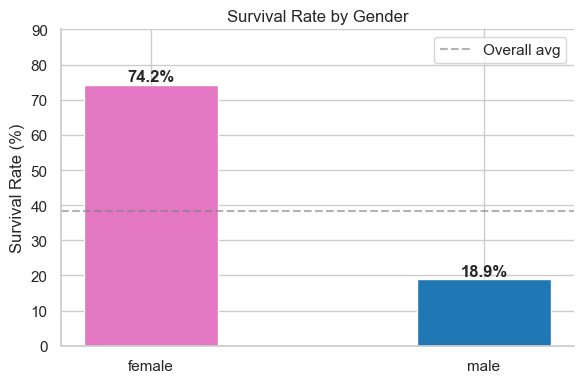

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

surv_sex = df_clean.groupby('Sex')['Survived'].mean() * 100
bars = ax.bar(surv_sex.index, surv_sex.values,
              color=['#e377c2', '#1f77b4'], edgecolor='white', width=0.4)

for bar, val in zip(bars, surv_sex.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.axhline(df_clean['Survived'].mean()*100, color='grey', linestyle='--', alpha=0.6, label='Overall avg')
ax.set_title('Survival Rate by Gender')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 90)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** The gap is stark - 74% of women survived compared to just 19% of men. This is the single largest driver of survival in the dataset and directly reflects the evacuation protocol.

### 5.3 Survival Rate by Passenger Class

Passenger class is a proxy for socioeconomic status. 1st-class cabins were higher up in the ship, closer to the lifeboats.

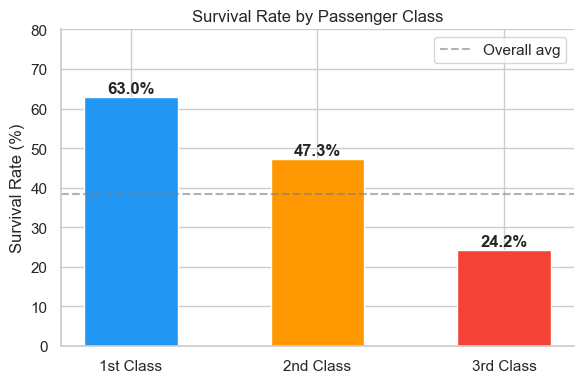

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

surv_class = df_clean.groupby('Pclass')['Survived'].mean() * 100
bars = ax.bar(['1st Class', '2nd Class', '3rd Class'], surv_class.values,
              color=['#2196F3', '#FF9800', '#F44336'], edgecolor='white', width=0.5)

for bar, val in zip(bars, surv_class.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.axhline(df_clean['Survived'].mean()*100, color='grey', linestyle='--', alpha=0.6, label='Overall avg')
ax.set_title('Survival Rate by Passenger Class')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** 1st-class passengers survived at 63%, 2nd at 47%, and 3rd at just 24%. Wealth and physical proximity to lifeboats both played a role.

### 5.4 Age Distribution

Looking at how age differed between survivors and non-survivors.

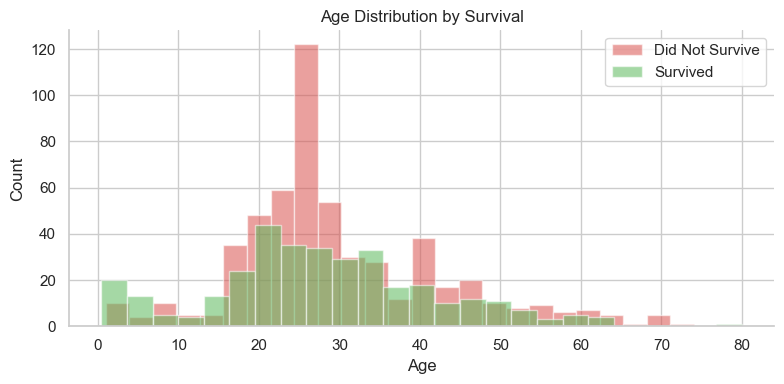

Median age — survived: 27.0
Median age — did not survive: 25.0


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

for survived, label, color in [(0, 'Did Not Survive', '#d9534f'), (1, 'Survived', '#5cb85c')]:
    subset = df_clean[df_clean['Survived'] == survived]['Age']
    ax.hist(subset, bins=25, alpha=0.55, label=label, color=color, edgecolor='white')

ax.set_title('Age Distribution by Survival')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print(f'Median age — survived: {df_clean[df_clean["Survived"]==1]["Age"].median():.1f}')
print(f'Median age — did not survive: {df_clean[df_clean["Survived"]==0]["Age"].median():.1f}')

**Observation:** Young children (under ~10) are more visible among survivors, consistent with child priority in lifeboat loading. The large peak of young adult males (20–35) is heavily represented among non-survivors.

### 5.5 Fare vs Survival

Fare is a more granular measure of wealth than class. Higher fares may reflect better cabin placement and lifeboat access.

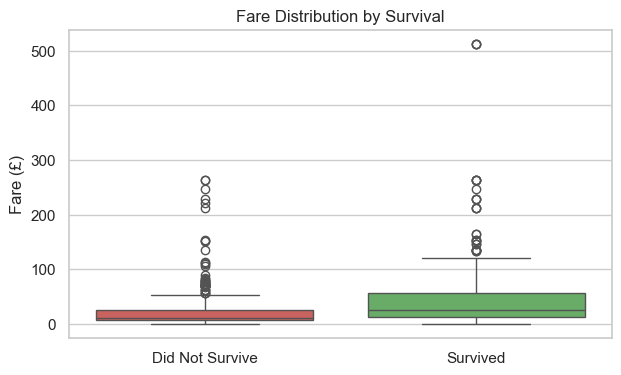

Median fare — survived: £26.00
Median fare — did not survive: £10.50


In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
survival_label = df_clean['Survived'].map(
    {0: 'Did Not Survive', 1: 'Survived'}
)
sns.boxplot(
    x=survival_label,
    y='Fare',
    data=df_clean,
    palette=['#d9534f', '#5cb85c'],
    ax=ax
)
ax.set_title('Fare Distribution by Survival')
ax.set_xlabel('')
ax.set_ylabel('Fare (£)')
plt.show()
print(f'Median fare — survived: £{df_clean[df_clean["Survived"]==1]["Fare"].median():.2f}')
print(f'Median fare — did not survive: £{df_clean[df_clean["Survived"]==0]["Fare"].median():.2f}')

**Observation:** Survivors paid a noticeably higher median fare (£26) than non-survivors (£11). This suggests that passengers who paid higher fares were more likely to survive. Since fare is strongly associated with passenger class, the result indicates that socioeconomic status may have influenced survival outcomes.

### 5.6 Survival Rate by Embarkation Port

The three ports were Southampton (S), Cherbourg (C), and Queenstown (Q). Any differences are likely explained by the class composition of passengers joining at each port.

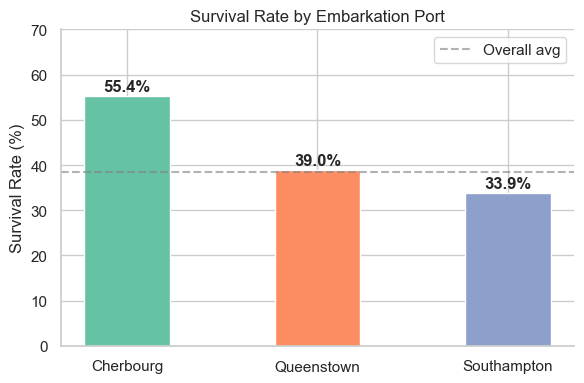

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

surv_port = df_clean.groupby('Embarked')['Survived'].mean() * 100
port_labels = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
surv_port.index = [port_labels[p] for p in surv_port.index]

bars = ax.bar(surv_port.index, surv_port.values,
              color=sns.color_palette('Set2', 3), edgecolor='white', width=0.45)

for bar, val in zip(bars, surv_port.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.axhline(df_clean['Survived'].mean()*100, color='grey', linestyle='--', alpha=0.6, label='Overall avg')
ax.set_title('Survival Rate by Embarkation Port')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 70)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** Cherbourg passengers had the highest survival rate (~55%), but this is largely because Cherbourg had a higher proportion of 1st-class passengers. The port itself is not the cause - class composition is.

### 5.7 Correlation Heatmap

A quick look at how all numeric features relate to survival and to each other.

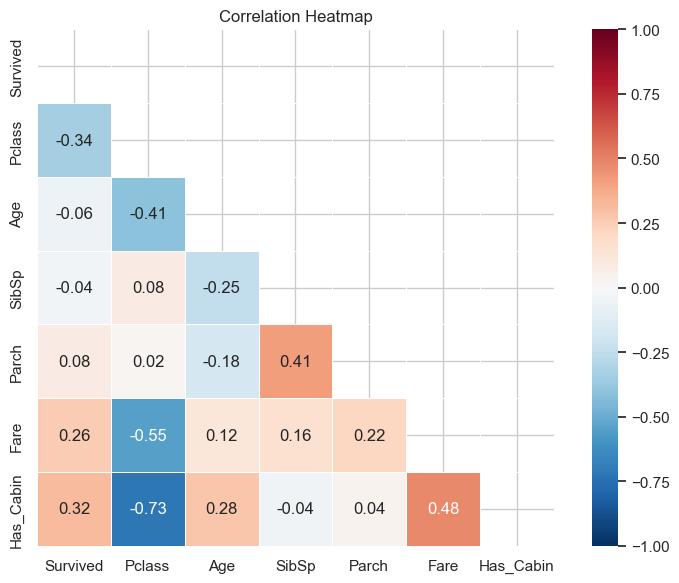

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin']
corr = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax)

ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observation:** `Pclass` has the strongest negative correlation with survival (-0.34) - higher class number means lower survival. `Fare` and `Has_Cabin` both correlate positively, reflecting the class link. `Age` has a weak negative relationship, and `Parch`/`SibSp` are near zero.

## 6. Findings

Survival on the Titanic was not random - it was shaped by gender, class, and to a lesser extent age and fare.

The analysis shows that survival on the Titanic was strongly influenced by passenger characteristics rather than chance. Gender was the most important factor, with female passengers having a much higher survival rate than male passengers. This pattern aligns with the historical “women and children first” evacuation policy.

Passenger class also played a significant role. First-class passengers had the highest survival rates, followed by second-class passengers, while third-class passengers experienced the lowest survival rates. Fare showed a similar pattern, as survivors generally paid higher fares than non-survivors, suggesting a link between socioeconomic status and access to safety.

Age had a weaker relationship with survival, although younger children appeared to have slightly better outcomes. Embarkation port showed some variation in survival rates, but its impact was less pronounced than gender or class.

Overall, the findings indicate that gender, passenger class, and fare were the strongest factors associated with survival, while age and embarkation port had comparatively smaller effects.